# Final 4: the complete final model

This is the project's final notebook. It contains the whole winning pipeline in one place - nothing is inherited from other notebooks except the spillover feature file (run `spillover.ipynb` first, exactly like final2 requires):

1. **DNS factors** - each day's 11 yields are compressed into level, slope, curvature with a decay chosen on training data only
2. **causal HSMM regime filter** - a hidden semi-markov model fit on the first 80%, then filtered forward so the probability at date t only uses data through t
3. **spillover features** - compact summaries of the Diebold-Yilmaz connectedness network
4. **VARX** - ridge regression that forecasts the CHANGE in each factor (so shrinkage pulls toward the random walk, not a historical average), plus an AR(1) forecast of each maturity's DNS fitting residual
5. **EWA combination** - the final model: an exponentially weighted average (Hedge) combiner that splits weight between the VARX and the observed-yield random walk based on discounted realized losses; it carries a textbook regret guarantee (Cesa-Bianchi and Lugosi 2006)
6. **full performance record** - accuracy, DM tests, an SPA-style bootstrap reality check that prices in the model search, and a turnover-netted trading evaluation with precommitted rules

Every tunable value is fixed a priori and written down before results are computed:

| parameter | value | reason |
|---|---|---|
| ridge/window grid | alpha in {0.1, 1, 10, 100, 1000}, window in {504, 1000, expanding} | selected on 40 training-only pseudo-origins by pure VARX accuracy |
| EWA discount gamma | 0.99 (effective window ~100 origins) | the discount is what lets the combiner re-enter after regime changes |
| EWA learning rate eta | sqrt(8 ln 2 / 100) ~ 0.2355 | textbook rate for 2 experts at effective horizon 100 |
| EWA weight floor alpha | 0.01 | output shrink toward 50/50 so both experts always keep at least 0.5% weight |
| trade threshold | 1 bp (sensitivity: 0, 0.5, 2, 4) | H.15 quantization unit; trade only when predicted edge >= cost |
| full-curve cost | 0.5 bp per round trip (stress 1.0) | stylized institutional cost |
| futures universe | 2Y, 5Y, 10Y, 30Y at 0.2/0.2/0.25/0.3 bp round trips (stress 2x) | tenors with liquid futures, tick-based costs |
| bootstrap | stationary bootstrap, mean block 2h, B = 2000, seed 7 | overlap-robust reality check (Politis-Romano 1994; Hansen 2005) |

Honest disclosure: this holdout was inspected repeatedly during development, so every number below is conditioned on that search. The SPA test prices in the four stored candidate models, but not the baseline notebooks or earlier tuning grids - those are covered only by this disclosure. The planned 3-month forward test is the only unconditioned evidence.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gaussian_hsmm import GaussianHSMM
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

#works whether jupyter starts in the repo root or in notebooks/
if Path("data/FRB_H15.csv").exists():
    dataDir = Path("data")
else:
    dataDir = Path("../data")

#the maturity names match final2/final3's saved files so results stay joinable
matList = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
maturityYears = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
dnsFactors = ["level", "slope", "curvature"]

horizons = [1, 5, 20]
maxHorizon = 20
dnsLagCount = 5

#model selection grids, identical to final2 so the VARX here reproduces final2's VARX
decayCandidates = np.arange(0.02, 0.801, 0.005)
ridgeCandidates = [0.1, 1.0, 10.0, 100.0, 1000.0]
windowCandidates = [504, 1000, None]
numTuningOrigins = 40
tuningSpacing = 5

#EWA combiner settings, all fixed a priori (see the table above)
ewaDiscount = 0.99
ewaEta = np.sqrt(8.0 * np.log(2.0) / 100.0)
ewaWeightFloor = 0.01

#trading settings, all fixed a priori
tradeThresholdBp = 1.0
thresholdSensitivity = [0.0, 0.5, 1.0, 2.0, 4.0]
fullCurveCostBp = 0.5
fullCurveCostStressBp = 1.0
futuresList = ["2Y", "5Y", "10Y", "30Y"]
futuresCostBp = {"2Y": 0.2, "5Y": 0.2, "10Y": 0.25, "30Y": 0.3}

#weighted directional accuracy robustness windows (origins) and step
backtestWindows = [63, 126, 252]
backtestStep = 21

#bootstrap settings
bootstrapReplications = 2000
bootstrapSeed = 7

#### Load data

All merges are by calendar date, never by row position (the sources have different holiday calendars). final2's and final3's saved ensembles are loaded only for the comparison table and the reality check - the model itself is built from scratch below.

Real-time availability convention: a value dated t is treated as known at the day-t close. This is exact for the H15 close, but the NY Fed publishes day-t EFFR (and FRED posts T5YIE) with a short lag, so the forward test must lag those two series one day.

In [2]:
#the H15 file has one date column and then the 11 maturities in order short to long
rawYields = pd.read_csv(dataDir / "FRB_H15.csv")
rawYields = rawYields.rename(columns={rawYields.columns[0]: "Date",
    rawYields.columns[1]: "1M", rawYields.columns[2]: "3M", rawYields.columns[3]: "6M",
    rawYields.columns[4]: "1Y", rawYields.columns[5]: "2Y", rawYields.columns[6]: "3Y",
    rawYields.columns[7]: "5Y", rawYields.columns[8]: "7Y", rawYields.columns[9]: "10Y",
    rawYields.columns[10]: "20Y", rawYields.columns[11]: "30Y"})
rawYields["Date"] = pd.to_datetime(rawYields["Date"], errors="coerce")
rawYields = rawYields.set_index("Date")

yieldDf = rawYields[matList]
yieldDf = yieldDf.apply(pd.to_numeric, errors="coerce")
yieldDf = yieldDf.dropna()
yieldDf = yieldDf.sort_index()

breakevenDf = pd.read_csv(dataDir / "T5YIE.csv")
breakevenDf = breakevenDf.rename(columns={"observation_date": "Date", "T5YIE": "breakeven"})
breakevenDf["Date"] = pd.to_datetime(breakevenDf["Date"])
breakevenDf = breakevenDf.set_index("Date")
breakevenDf = breakevenDf[["breakeven"]]
breakevenDf = breakevenDf.apply(pd.to_numeric, errors="coerce")
breakevenDf = breakevenDf.dropna()
breakevenDf = breakevenDf.sort_index()

effrDf = pd.read_csv(dataDir / "EFFR.csv")
effrDf = effrDf.rename(columns={"observation_date": "Date", "EFFR": "effr"})
effrDf["Date"] = pd.to_datetime(effrDf["Date"])
effrDf = effrDf.set_index("Date")
effrDf = effrDf[["effr"]]
effrDf = effrDf.apply(pd.to_numeric, errors="coerce")
effrDf = effrDf.dropna()
effrDf = effrDf.sort_index()

#the policy spread compares the market 2 year rate with the overnight policy rate
policyDf = yieldDf[["2Y"]].join(effrDf, how="left")
policyDf["policySpread"] = policyDf["2Y"] - policyDf["effr"]

spilloverFile = dataDir / "generated" / "spillover_features.csv"
if not spilloverFile.exists():
    raise FileNotFoundError("run spillover.ipynb first, it creates spillover_features.csv")
spilloverDf = pd.read_csv(spilloverFile, parse_dates=["date"])
spilloverDf = spilloverDf.set_index("date")

#stored ensembles from final2/final3, used only for comparison and the reality check
final2Forecasts = pd.read_csv(dataDir / "generated" / "final2_results" / "yield_forecasts.csv",
    parse_dates=["origin_date", "target_date"])
final3Forecasts = pd.read_csv(dataDir / "generated" / "final3_results" / "yield_forecasts.csv",
    parse_dates=["origin_date", "target_date"])

print("complete curves:", len(yieldDf))
print("range:", yieldDf.index.min().date(), "to", yieldDf.index.max().date())

complete curves: 6199
range: 2001-07-31 to 2026-05-14


#### DNS factors with training-only decay

The Nelson-Siegel curve says the yield at maturity tau is a mix of three shapes: a constant (level), a shape that is big at the short end and fades (slope), and a hump in the middle (curvature). With the decay fixed, the three shapes form a constant 11x3 loading matrix, and each day's three factors are an ordinary least squares fit of that day's 11 yields onto it (pinv is the OLS projection). Day t factors use only day t yields, so this step cannot leak.

The decay is chosen once, on the first 80% of the aligned sample only, by curve-fit rmse. A guard assert fails loudly if a future data refresh ever pushes that 80% boundary into the evaluated period.

In [3]:
def nsLoadings(maturities, decay):
    #one [level, slope, curvature] loading row per maturity
    scaled = decay * maturities
    slopeLoad = (1.0 - np.exp(-scaled)) / scaled
    curveLoad = slopeLoad - np.exp(-scaled)
    levelLoad = np.ones(len(maturities))
    return np.column_stack([levelLoad, slopeLoad, curveLoad])


def estimateDnsFactors(yieldFrame, decay):
    #per-date cross sectional OLS: factors = pinv(L) @ yields
    loadingMatrix = nsLoadings(maturityYears, decay)
    projection = np.linalg.pinv(loadingMatrix)
    factorArray = yieldFrame.to_numpy() @ projection.T
    reconstructed = factorArray @ loadingMatrix.T

    factorsDf = pd.DataFrame(factorArray, index=yieldFrame.index, columns=dnsFactors)
    residualsDf = yieldFrame - pd.DataFrame(reconstructed, index=yieldFrame.index, columns=matList)
    return factorsDf, residualsDf, loadingMatrix


#align on macro availability, then keep the first 80% for decay selection
aligned = yieldDf.join(breakevenDf, how="inner")
aligned = aligned.join(policyDf[["policySpread"]], how="inner")
aligned = aligned.join(spilloverDf[["total_connectedness"]], how="inner")
aligned = aligned.dropna()

decayTrainEnd = int(0.80 * len(aligned))
decayTrainDates = aligned.index[:decayTrainEnd]

#guard: decay selection must never touch the evaluated period
firstEvaluatedOrigin = final2Forecasts["origin_date"].min()
assert decayTrainDates[-1] < firstEvaluatedOrigin, "decay window reaches into evaluated origins"

decayTrainYields = yieldDf.loc[decayTrainDates]

decayRows = []
for candidate in decayCandidates:
    factorsTemp, residualsTemp, loadTemp = estimateDnsFactors(decayTrainYields, candidate)
    fitRmse = 100.0 * np.sqrt(np.mean(residualsTemp.to_numpy() ** 2))
    decayRows.append([candidate, fitRmse])

decayResults = pd.DataFrame(decayRows, columns=["decay", "trainCurveRmseBp"])
bestRow = decayResults["trainCurveRmseBp"].idxmin()
selectedDecay = decayResults["decay"].iloc[bestRow]

dnsDf, residualsDf, loadingMatrix = estimateDnsFactors(yieldDf, selectedDecay)

print("selected decay (training only):", round(selectedDecay, 4))
print("decay training ends:", decayTrainDates[-1].date())

selected decay (training only): 0.485
decay training ends: 2021-09-08


#### Causal HSMM regime filter

A hidden semi-markov model says the economy sits in one of three unobserved regimes, each with its own typical values for five inputs (level, slope, curvature, breakeven inflation, policy spread) and its own explicit duration distribution (how long a spell lasts). The parameters are fit only on the first 80%.

The standard `predict_proba` gives SMOOTHED probabilities - the probability at date t uses the whole series including the future, which would leak. The filter below fixes that: it expands each regime into (regime, remaining duration) pairs and walks forward one day at a time:

1. spells with more than one day remaining lose one day
2. spells that finish jump to a new regime and draw a new duration
3. everything is multiplied by how well today's data fits each regime, then normalized

Because the recursion only moves forward, the probability at date t uses data only through t.

In [4]:
hsmmInputDf = dnsDf.join(breakevenDf, how="inner")
hsmmInputDf = hsmmInputDf.join(policyDf[["policySpread"]], how="inner")
hsmmInputDf = hsmmInputDf.dropna()
hsmmInputDf = hsmmInputDf.sort_index()

hsmmTrainEnd = int(0.80 * len(hsmmInputDf))
hsmmTrainDf = hsmmInputDf.iloc[:hsmmTrainEnd]

#standardize with training-only mean and scale so later data cannot influence preprocessing
hsmmScaler = StandardScaler()
hsmmTrainArray = hsmmScaler.fit_transform(hsmmTrainDf)
hsmmAllArray = hsmmScaler.transform(hsmmInputDf)

hsmmModel = GaussianHSMM(
    n_components=3,
    covariance_type="diag",
    max_duration=126,
    n_iter=6,
    hmm_n_iter=500,
    tol=1e-3,
    min_covar=1e-4,
    random_state=42,
)
hsmmModel = hsmmModel.fit(hsmmTrainArray)


def gaussianLogLikelihood(observations, means, variances):
    #log p(observation at t | regime j) for every date and regime
    logLik = np.empty((len(observations), len(means)))
    for state in range(len(means)):
        stateVar = np.maximum(variances[state], 1e-12)
        squaredDist = (observations - means[state]) ** 2 / stateVar
        logLik[:, state] = -0.5 * np.sum(np.log(2.0 * np.pi * stateVar) + squaredDist, axis=1)
    return logLik


def causalHsmmFilter(model, observations):
    #forward filter over the expanded (regime, remaining duration) space
    numStates = model.n_components
    maxDuration = model.max_duration
    durations = np.arange(1, maxDuration + 1)

    logEmissions = gaussianLogLikelihood(observations, model.means_, model.covars_)

    #duration_probs_ has an unused duration-zero column, slice it off
    durationProbs = model.duration_probs_[:, 1 : maxDuration + 1]

    filteredProbs = np.zeros((len(observations), numStates))
    expectedRemaining = np.zeros(len(observations))

    #before the first observation: pick a start regime and a full spell duration
    expanded = model.startprob_[:, None] * durationProbs

    for t in range(len(observations)):
        if t > 0:
            predicted = np.zeros((numStates, maxDuration))

            #a spell with remaining duration r > 1 continues with r - 1
            predicted[:, :-1] = predicted[:, :-1] + expanded[:, 1:]

            #mass at remaining duration 1 finishes today: transition to a new
            #regime and spread that mass over the new regime's durations
            finishedMass = expanded[:, 0]
            enteringMass = finishedMass @ model.transmat_
            predicted = predicted + enteringMass[:, None] * durationProbs
            expanded = predicted

        #multiply by today's fit to each regime; subtracting the max avoids underflow
        scaledEmission = np.exp(logEmissions[t] - logEmissions[t].max())
        expanded = expanded * scaledEmission[:, None]
        total = expanded.sum()
        assert total > 0.0 and np.isfinite(total), "hsmm filter collapsed numerically"

        expanded = expanded / total
        filteredProbs[t] = expanded.sum(axis=1)
        expectedRemaining[t] = np.sum(expanded * durations[None, :])

    return filteredProbs, expectedRemaining


filteredProbs, expectedRemaining = causalHsmmFilter(hsmmModel, hsmmAllArray)
assert np.allclose(filteredProbs.sum(axis=1), 1.0)

regimeDf = pd.DataFrame(index=hsmmInputDf.index)
for state in range(hsmmModel.n_components):
    regimeDf["filteredState" + str(state) + "Prob"] = filteredProbs[:, state]

#confidence is near 1 when one regime dominates; entropy is high when uncertain
safeProbs = np.clip(filteredProbs, 1e-12, 1.0)
regimeDf["stateConfidence"] = filteredProbs.max(axis=1)
regimeDf["stateEntropy"] = -np.sum(safeProbs * np.log(safeProbs), axis=1)
regimeDf["expectedRemainingDuration"] = expectedRemaining

regimeFeatureNames = list(regimeDf.columns)
print("hsmm training ends:", hsmmTrainDf.index[-1].date())
print("regime features:", regimeFeatureNames)

hsmm training ends: 2021-09-08
regime features: ['filteredState0Prob', 'filteredState1Prob', 'filteredState2Prob', 'stateConfidence', 'stateEntropy', 'expectedRemainingDuration']


#### Spillover features, modeling table, and the holdout

The network features are collapsed into compact, economically readable pieces: three global intensity measures, net transmission for the short end / belly / long end, their difference, and 5 day changes.

The holdout must start strictly after every training-only design choice: the HSMM fit boundary, the decay selection boundary, and the spillover VAR-lag selection boundary that spillover.ipynb exports. The evaluated origins are every holdout day whose 20 day target is still inside the sample.

In [5]:
compactDf = pd.DataFrame(index=spilloverDf.index)
compactDf["totalConnectedness"] = spilloverDf["total_connectedness"]
compactDf["maximumEdge"] = spilloverDf["maximum_edge"]
compactDf["averageAbsoluteNet"] = spilloverDf["average_absolute_net"]

#curve regions: short end, belly, long end
compactDf["shortNetTransmission"] = spilloverDf[["net_1M", "net_3M", "net_6M", "net_1Y"]].mean(axis=1)
compactDf["bellyNetTransmission"] = spilloverDf[["net_2Y", "net_3Y", "net_5Y", "net_7Y"]].mean(axis=1)
compactDf["longNetTransmission"] = spilloverDf[["net_10Y", "net_20Y", "net_30Y"]].mean(axis=1)
compactDf["longMinusShortTransmission"] = compactDf["longNetTransmission"] - compactDf["shortNetTransmission"]
compactDf["connectednessChange5d"] = compactDf["totalConnectedness"].diff(5)
compactDf["longNetChange5d"] = compactDf["longNetTransmission"].diff(5)

spilloverFeatureNames = list(compactDf.columns)

#one aligned modeling table: factors, regimes, network, observed yields, residuals
modelDf = dnsDf.join(regimeDf, how="inner")
modelDf = modelDf.join(compactDf, how="inner")
modelDf = modelDf.join(yieldDf.add_prefix("observed_"), how="inner")
modelDf = modelDf.join(residualsDf.add_prefix("residual_"), how="inner")
modelDf = modelDf.dropna()
modelDf = modelDf.sort_index()

observedCols = []
for mat in matList:
    observedCols.append("observed_" + mat)

#holdout starts after the LATEST training-only design boundary
designBoundaries = [hsmmTrainDf.index[-1], decayTrainDates[-1]]
spilloverBoundaryFile = dataDir / "generated" / "spillover_design_boundary.txt"
if spilloverBoundaryFile.exists():
    designBoundaries.append(pd.Timestamp(spilloverBoundaryFile.read_text().strip()))
else:
    print("WARNING: spillover_design_boundary.txt missing, re-run spillover.ipynb")

lastTrainingDate = max(designBoundaries)
holdoutStart = int(modelDf.index.searchsorted(lastTrainingDate, side="right"))

forecastOrigins = []
for position in range(holdoutStart, len(modelDf) - maxHorizon):
    forecastOrigins.append(position)

boundaryDates = []
for boundary in designBoundaries:
    boundaryDates.append(boundary.date())
print("aligned rows:", len(modelDf))
print("design boundaries:", boundaryDates)
print("evaluated origins:", len(forecastOrigins))
print("first origin:", modelDf.index[forecastOrigins[0]].date())
print("last 20 day target:", modelDf.index[forecastOrigins[-1] + maxHorizon].date())

aligned rows: 5841
design boundaries: [datetime.date(2021, 9, 8), datetime.date(2021, 9, 8), datetime.date(2021, 5, 27)]
evaluated origins: 1149
first origin: 2021-09-09
last 20 day target: 2026-05-14


#### Supervised construction (change space)

The predictor row at origin t holds the factors at t, t-1, ..., t-4 plus the regime and spillover features at t. The target for horizon h is the factor CHANGE f(t+h) - f(t): under ridge shrinkage a change-space model collapses to "no change" - the random walk - instead of the training-average level, which is the correct default for persistent yields. The level forecast later adds the current factors back.

A training sample for origin t may only contain origins o with o + h <= t, so every training target is realized by the time the forecast is made. The predictor matrix and targets are built once with shift() so a training sample is just a row slice (hundreds of origins would be too slow otherwise).

In [6]:
#predictor matrix built once: row t holds everything known at t
predictorDf = pd.DataFrame(index=modelDf.index)
for lag in range(dnsLagCount):
    for factor in dnsFactors:
        predictorDf["dns_" + factor + "_lag" + str(lag)] = modelDf[factor].shift(lag)
for feature in regimeFeatureNames:
    predictorDf[feature] = modelDf[feature]
for feature in spilloverFeatureNames:
    predictorDf[feature] = modelDf[feature]
predictorNames = list(predictorDf.columns)

#one change target table per horizon: row t holds factors(t+h) - factors(t)
changeTargets = {}
for horizon in horizons:
    changeTargets[horizon] = modelDf[dnsFactors].shift(-horizon) - modelDf[dnsFactors]


def makeTrainingSlice(horizon, origin, windowLength):
    #last usable training origin is origin - horizon (its target lands exactly on the origin)
    lastTrain = origin - horizon
    firstTrain = dnsLagCount - 1
    if windowLength is not None:
        firstTrain = max(firstTrain, lastTrain - windowLength + 1)
    xTrain = predictorDf.iloc[firstTrain : lastTrain + 1]
    yTrain = changeTargets[horizon].iloc[firstTrain : lastTrain + 1].to_numpy(dtype=float)
    return xTrain, yTrain


def forecastResiduals(origin, horizon):
    #AR(1) per maturity on the DNS fit residuals, re-estimated from the trailing 1000 days
    forecasts = []
    historyStart = max(0, origin - 1000 + 1)
    for mat in matList:
        history = modelDf["residual_" + mat].iloc[historyStart : origin + 1].to_numpy()
        lagged = history[:-1]
        current = history[1:]
        design = np.column_stack([np.ones(len(lagged)), lagged])
        coeffs = np.linalg.lstsq(design, current, rcond=None)[0]
        intercept = coeffs[0]
        persistence = np.clip(coeffs[1], -0.99, 0.99)
        if abs(1.0 - persistence) > 1e-8:
            longRunMean = intercept / (1.0 - persistence)
        else:
            longRunMean = history.mean()
        forecasts.append(longRunMean + persistence ** horizon * (history[-1] - longRunMean))
    return np.array(forecasts)


def fitRidgeAndPredict(horizon, origin, windowLength, ridgeAlpha):
    #scaler and ridge written out in full so each step is visible
    xTrain, yTrain = makeTrainingSlice(horizon, origin, windowLength)
    scaler = StandardScaler()
    xTrainScaled = scaler.fit_transform(xTrain)
    ridgeModel = Ridge(alpha=ridgeAlpha)
    ridgeModel.fit(xTrainScaled, yTrain)
    xCurrent = predictorDf.iloc[[origin]]
    xCurrentScaled = scaler.transform(xCurrent)
    predictedChange = ridgeModel.predict(xCurrentScaled)[0]
    return predictedChange


#sanity checks before any model is fit
checkOrigin = forecastOrigins[0]
handChange = (modelDf[dnsFactors].iloc[checkOrigin + 1].to_numpy(dtype=float)
              - modelDf[dnsFactors].iloc[checkOrigin].to_numpy(dtype=float))
assert np.allclose(changeTargets[1].iloc[checkOrigin].to_numpy(dtype=float), handChange)
assert not predictorDf.iloc[dnsLagCount - 1 :].isna().any().any()
print("predictors:", len(predictorNames))

predictors: 30


#### Training-only tuning

Forty pseudo-origins spaced a week apart, ending a full 20 trading days before the holdout, so every tuning outcome is observable before evaluation starts. The window and ridge penalty are selected by pure VARX accuracy. The EWA combiner needs no tuned starting weight - it begins at 50/50 by construction (a uniform prior over the two experts) and lets realized losses move it.

In [7]:
lastTuningOrigin = holdoutStart - maxHorizon
tuningOrigins = []
for step in range(numTuningOrigins - 1, -1, -1):
    tuningOrigins.append(lastTuningOrigin - tuningSpacing * step)
assert tuningOrigins[-1] + maxHorizon <= holdoutStart
assert tuningOrigins[0] > dnsLagCount - 1 + 250, "too little history before the first tuning origin"

selectedSettings = {}
tuningRows = []

for horizon in horizons:
    #quantities that do not depend on (window, alpha), computed once per tuning origin
    commonPerOrigin = []
    for origin in tuningOrigins:
        actualYields = modelDf[observedCols].iloc[origin + horizon].to_numpy(dtype=float)
        residualForecast = forecastResiduals(origin, horizon)
        currentFactors = modelDf[dnsFactors].iloc[origin].to_numpy(dtype=float)
        commonPerOrigin.append([actualYields, residualForecast, currentFactors])

    bestWindow = None
    bestAlpha = None
    bestRmse = np.inf
    for windowLength in windowCandidates:
        for ridgeAlpha in ridgeCandidates:
            squaredErrors = []
            for originIndex in range(len(tuningOrigins)):
                origin = tuningOrigins[originIndex]
                predictedChange = fitRidgeAndPredict(horizon, origin, windowLength, ridgeAlpha)
                actualYields = commonPerOrigin[originIndex][0]
                residualForecast = commonPerOrigin[originIndex][1]
                currentFactors = commonPerOrigin[originIndex][2]
                varxForecast = loadingMatrix @ (currentFactors + predictedChange) + residualForecast
                for error in (actualYields - varxForecast):
                    squaredErrors.append(error ** 2)
            rmseBp = 100.0 * np.sqrt(np.mean(squaredErrors))
            if windowLength is None:
                windowLabel = "expanding"
            else:
                windowLabel = windowLength
            tuningRows.append([horizon, windowLabel, ridgeAlpha, rmseBp])
            if rmseBp < bestRmse:
                bestRmse = rmseBp
                bestWindow = windowLength
                bestAlpha = ridgeAlpha

    selectedSettings[horizon] = {"window": bestWindow, "alpha": bestAlpha, "varxTuningRmseBp": bestRmse}
    print("horizon", horizon, "-> window:", bestWindow, " alpha:", bestAlpha,
          " varx tuning rmse:", round(bestRmse, 3), "bp")

tuningResults = pd.DataFrame(tuningRows, columns=["horizon", "window", "ridgeAlpha", "tuningRmseBp"])

horizon 1 -> window: None  alpha: 1000.0  varx tuning rmse: 2.927 bp


horizon 5 -> window: None  alpha: 1000.0  varx tuning rmse: 5.408 bp


horizon 20 -> window: None  alpha: 1000.0  varx tuning rmse: 13.857 bp


#### Evaluation loop: VARX, random walk, and the EWA combination

At every origin the notebook produces three forecasts: the observed-yield random walk, the VARX, and the final model - their EWA combination.

How the EWA weight works at origin t:

1. absorb every origin o whose outcome is realized by now (o + h <= t): compute each expert's squared error, normalize by a discounted running mean of the random walk error (so the learning rate is scale free), and add it to that expert's discounted loss total
2. the weight on the VARX is softmax of minus eta times the two loss totals
3. shrink the weight a little toward 50/50 (the floor) so both experts always stay alive

The discount makes old losses fade, which is what lets the combiner re-enter an expert after a regime change. Today's own outcome is absorbed only after today's weight is chosen, so nothing leaks.

finished origin 200 of 1149


finished origin 400 of 1149


finished origin 600 of 1149


finished origin 800 of 1149


finished origin 1000 of 1149


finished origin 1149 of 1149


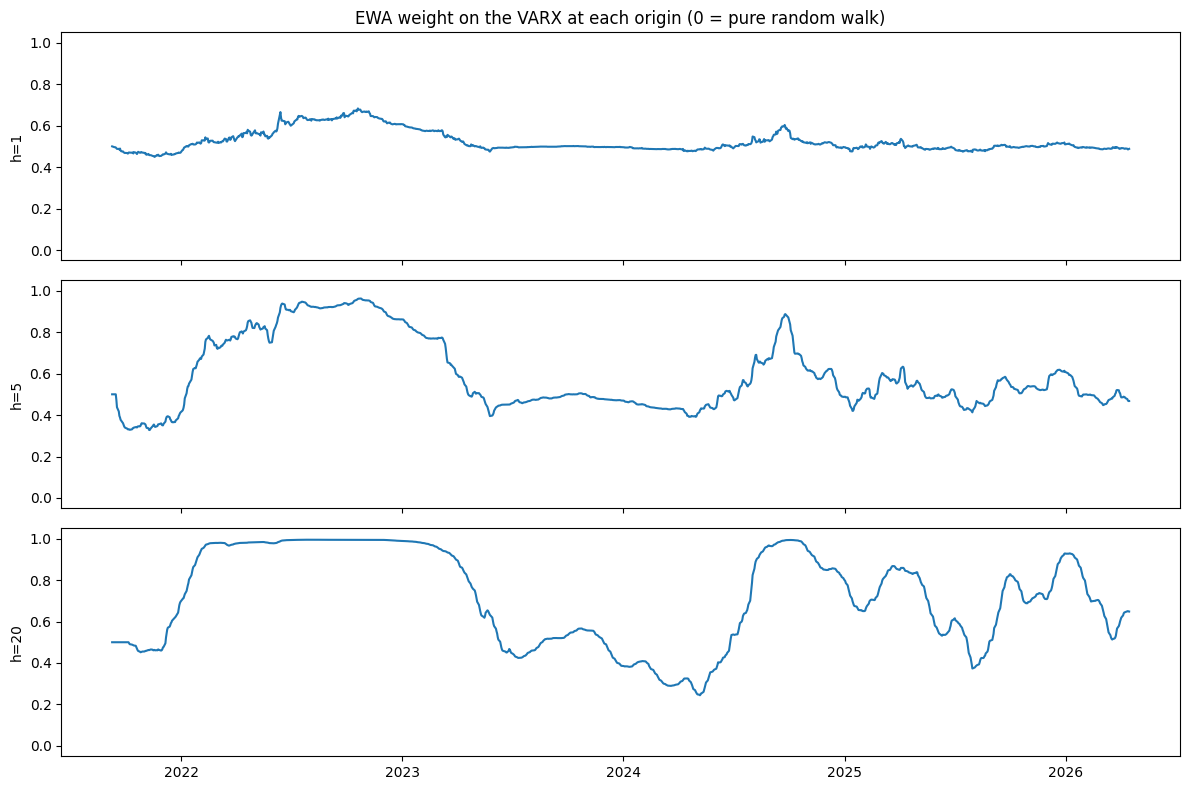

In [8]:
forecastRows = []

#per horizon EWA state: discounted loss totals, the normalizer, and how far we absorbed
ewaState = {}
for horizon in horizons:
    ewaState[horizon] = {"varxLossSum": 0.0, "walkLossSum": 0.0,
                         "normalizerSum": 0.0, "normalizerCount": 0.0, "absorbedUpTo": 0}

#realized per-origin results per horizon, in origin order, for the absorb step
realizedResults = {}
for horizon in horizons:
    realizedResults[horizon] = []

ewaWeightRows = []

originNumber = 0
for origin in forecastOrigins:
    originNumber = originNumber + 1
    for horizon in horizons:
        settings = selectedSettings[horizon]
        predictedChange = fitRidgeAndPredict(horizon, origin, settings["window"], settings["alpha"])
        currentFactors = modelDf[dnsFactors].iloc[origin].to_numpy(dtype=float)

        varxForecast = loadingMatrix @ (currentFactors + predictedChange) + forecastResiduals(origin, horizon)
        walkForecast = modelDf[observedCols].iloc[origin].to_numpy(dtype=float)

        #step 1: absorb every origin whose outcome is realized by now (o + h <= t)
        state = ewaState[horizon]
        originIndexNow = originNumber - 1
        while state["absorbedUpTo"] + horizon <= originIndexNow:
            absorbed = realizedResults[horizon][state["absorbedUpTo"]]
            varxLoss = np.mean((absorbed[2] - absorbed[0]) ** 2)
            walkLoss = np.mean((absorbed[2] - absorbed[1]) ** 2)

            #discounted running mean of the walk loss keeps eta scale free
            state["normalizerSum"] = ewaDiscount * state["normalizerSum"] + walkLoss
            state["normalizerCount"] = ewaDiscount * state["normalizerCount"] + 1.0
            normalizer = state["normalizerSum"] / state["normalizerCount"]
            #floor guards the degenerate case of a zero walk loss (all maturities
            #unchanged at the 1bp quantization); it never binds on current data
            if normalizer < 1e-6:
                normalizer = 1e-6

            state["varxLossSum"] = ewaDiscount * state["varxLossSum"] + varxLoss / normalizer
            state["walkLossSum"] = ewaDiscount * state["walkLossSum"] + walkLoss / normalizer
            state["absorbedUpTo"] = state["absorbedUpTo"] + 1

        #step 2: softmax of minus eta times the discounted losses (two experts)
        varxScore = np.exp(-ewaEta * state["varxLossSum"])
        walkScore = np.exp(-ewaEta * state["walkLossSum"])
        weightVarx = varxScore / (varxScore + walkScore)

        #step 3: weight floor, shrink a little toward 50/50 so both experts stay alive
        weightVarx = (1.0 - ewaWeightFloor) * weightVarx + ewaWeightFloor * 0.5

        ensembleForecast = weightVarx * varxForecast + (1.0 - weightVarx) * walkForecast

        targetPosition = origin + horizon
        actualYields = modelDf[observedCols].iloc[targetPosition].to_numpy(dtype=float)

        #recorded after the weight is chosen, so today's outcome cannot inform today's weight
        realizedResults[horizon].append([varxForecast, walkForecast, actualYields])
        ewaWeightRows.append([modelDf.index[origin], horizon, weightVarx])

        modelForecasts = [["Random Walk", walkForecast],
                          ["VARX", varxForecast],
                          ["final4 EWA Ensemble", ensembleForecast]]
        for pair in modelForecasts:
            modelName = pair[0]
            predictedYields = pair[1]
            for matIndex in range(len(matList)):
                forecastRows.append({
                    "origin_date": modelDf.index[origin],
                    "target_date": modelDf.index[targetPosition],
                    "horizon": horizon,
                    "model": modelName,
                    "maturity": matList[matIndex],
                    "ewa_weight": weightVarx,
                    "origin_yield": walkForecast[matIndex],
                    "actual_yield": actualYields[matIndex],
                    "predicted_yield": predictedYields[matIndex],
                })

    if originNumber % 200 == 0 or originNumber == len(forecastOrigins):
        print("finished origin", originNumber, "of", len(forecastOrigins))

yieldForecasts = pd.DataFrame(forecastRows)
assert len(yieldForecasts) == len(forecastOrigins) * 3 * 3 * 11
assert not yieldForecasts.isna().any().any()

weightPathDf = pd.DataFrame(ewaWeightRows, columns=["origin_date", "horizon", "ewaWeight"])
fig, axes = plt.subplots(len(horizons), 1, figsize=(12, 8), sharex=True)
for axisIndex in range(len(horizons)):
    horizon = horizons[axisIndex]
    path = weightPathDf[weightPathDf["horizon"] == horizon]
    axes[axisIndex].plot(path["origin_date"], path["ewaWeight"])
    axes[axisIndex].set_ylabel("h=" + str(horizon))
    axes[axisIndex].set_ylim(-0.05, 1.05)
axes[0].set_title("EWA weight on the VARX at each origin (0 = pure random walk)")
plt.tight_layout()
plt.show()

#### Accuracy, DM tests, and the reality check

The accuracy table covers every model in the project: the in-notebook random walk, VARX, and final4 EWA ensemble, plus final2's and final3's stored ensembles merged in on identical origin dates. A consistency check confirms the in-notebook VARX reproduces final2's stored VARX (same specification, so any real difference means the pipeline diverged).

DM tests use the rectangular kernel through lag h-1 (overlapping errors have positive autocovariances there, so downweighting would overstate significance), the HLN small-sample correction, and BH q-values.

The SPA-style reality check answers "is the best model still significant after accounting for the search across candidates?" - stationary bootstrap with mean block 2h so resampled series keep the overlap correlation, best studentized performance as the statistic, and Hansen's recentering and max(0, .) floors.

In [9]:
#merge the stored final2/final3 ensembles on identical origin dates
final2EnsDf = final2Forecasts[final2Forecasts["model"] == "Adaptive Ensemble"]
final2EnsDf = final2EnsDf[["origin_date", "horizon", "maturity", "predicted_yield"]]
final2EnsDf = final2EnsDf.rename(columns={"predicted_yield": "final2Predicted"})

final3EnsDf = final3Forecasts[final3Forecasts["model"] == "Econ Adaptive Ensemble"]
final3EnsDf = final3EnsDf[["origin_date", "horizon", "maturity", "predicted_yield"]]
final3EnsDf = final3EnsDf.rename(columns={"predicted_yield": "final3Predicted"})

final2VarxDf = final2Forecasts[final2Forecasts["model"] == "Residual-corrected VARX"]
final2VarxDf = final2VarxDf[["origin_date", "horizon", "maturity", "predicted_yield"]]
final2VarxDf = final2VarxDf.rename(columns={"predicted_yield": "final2VarxPredicted"})

wideDf = yieldForecasts.pivot(index=["origin_date", "horizon", "maturity"],
                              columns="model", values="predicted_yield")
wideDf = wideDf.reset_index()
wideDf = wideDf.rename(columns={"Random Walk": "walkPredicted", "VARX": "varxPredicted",
                                "final4 EWA Ensemble": "final4Predicted"})
baseDf = yieldForecasts[yieldForecasts["model"] == "Random Walk"]
baseDf = baseDf[["origin_date", "horizon", "maturity", "origin_yield", "actual_yield"]]
wideDf = wideDf.merge(baseDf, on=["origin_date", "horizon", "maturity"])
wideDf = wideDf.merge(final2EnsDf, on=["origin_date", "horizon", "maturity"], how="left")
wideDf = wideDf.merge(final3EnsDf, on=["origin_date", "horizon", "maturity"], how="left")
wideDf = wideDf.merge(final2VarxDf, on=["origin_date", "horizon", "maturity"], how="left")

#consistency check: the in-notebook varx must reproduce final2's stored varx
checkDf = wideDf.dropna(subset=["final2VarxPredicted"])
maxDiff = (checkDf["varxPredicted"] - checkDf["final2VarxPredicted"]).abs().max()
print("max |in-notebook varx - final2 stored varx| =", maxDiff)
assert maxDiff < 1e-4, "pipeline diverged from final2's varx, investigate before trusting results"

modelColumns = [["Random Walk", "walkPredicted"],
                ["VARX", "varxPredicted"],
                ["final2 Adaptive Ensemble", "final2Predicted"],
                ["final3 Econ Ensemble", "final3Predicted"],
                ["final4 EWA Ensemble", "final4Predicted"]]

metricRows = []
for pair in modelColumns:
    modelName = pair[0]
    column = pair[1]
    for horizon in horizons:
        rows = wideDf[wideDf["horizon"] == horizon].dropna(subset=[column])
        errors = 100.0 * (rows["actual_yield"] - rows[column]).to_numpy()
        rmse = np.sqrt(np.mean(errors ** 2))
        mae = np.mean(np.abs(errors))

        predictedSign = np.sign((rows[column] - rows["origin_yield"]).to_numpy())
        actualSign = np.sign((rows["actual_yield"] - rows["origin_yield"]).to_numpy())
        #scorable rows need BOTH signs nonzero: the walk predicts exactly zero change,
        #and quantized yields make some realized changes exactly zero (unwinnable ties)
        scorable = (predictedSign != 0) & (actualSign != 0)
        if scorable.sum() > 0:
            directionalAccuracy = np.mean(predictedSign[scorable] == actualSign[scorable])
        else:
            directionalAccuracy = np.nan

        nonzeroActual = actualSign[actualSign != 0]
        upShare = np.mean(nonzeroActual > 0)
        baseRate = max(upShare, 1.0 - upShare)

        metricRows.append([modelName, horizon, rmse, mae, directionalAccuracy, baseRate])

accuracyTable = pd.DataFrame(metricRows,
    columns=["model", "horizon", "curveRmseBp", "curveMaeBp", "directionalAccuracy", "daBaseRate"])
accuracyTable = accuracyTable.sort_values(["horizon", "curveRmseBp"])
display(accuracyTable.round(4))


def dieboldMariano(lossA, lossB, horizon):
    #classic DM with rectangular kernel through lag h-1 and the HLN small sample correction
    difference = np.asarray(lossA) - np.asarray(lossB)
    n = len(difference)
    centered = difference - difference.mean()
    maxLag = min(horizon - 1, n - 2)
    variance = np.dot(centered, centered) / n
    for lag in range(1, maxLag + 1):
        variance = variance + 2.0 * np.dot(centered[lag:], centered[:-lag]) / n
    if variance <= 0.0:
        return np.nan, np.nan
    statistic = difference.mean() / np.sqrt(variance / n)
    correction = (n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n
    statistic = statistic * np.sqrt(correction)
    pValue = 2.0 * stats.t.sf(abs(statistic), df=n - 1)
    return statistic, pValue


#per-origin curve losses as date-indexed series so comparisons align on common days
originLoss = {}
for pair in modelColumns:
    modelName = pair[0]
    column = pair[1]
    originLoss[modelName] = {}
    for horizon in horizons:
        rows = wideDf[wideDf["horizon"] == horizon].dropna(subset=[column])
        squared = (100.0 * (rows["actual_yield"] - rows[column])) ** 2
        perOrigin = squared.groupby(rows["origin_date"]).mean().sort_index()
        originLoss[modelName][horizon] = perOrigin

dmRows = []
dmPairs = [["final4 EWA Ensemble", "Random Walk"],
           ["final4 EWA Ensemble", "final2 Adaptive Ensemble"],
           ["final2 Adaptive Ensemble", "Random Walk"]]
for horizon in horizons:
    for pair in dmPairs:
        joined = pd.concat([originLoss[pair[0]][horizon].rename("lossA"),
                            originLoss[pair[1]][horizon].rename("lossB")], axis=1, join="inner")
        statistic, pValue = dieboldMariano(joined["lossA"].to_numpy(), joined["lossB"].to_numpy(), horizon)
        dmRows.append([horizon, pair[0], pair[1], statistic, pValue])

dmResults = pd.DataFrame(dmRows, columns=["horizon", "modelA", "modelB", "dmStatistic", "pValue"])
finiteMask = dmResults["pValue"].notna().to_numpy()
qValues = np.full(len(dmResults), np.nan)
qValues[finiteMask] = stats.false_discovery_control(dmResults["pValue"].to_numpy()[finiteMask])
dmResults["qValueBH"] = qValues
print("negative dmStatistic favors modelA")
display(dmResults.round(4))


def stationaryBootstrapIndexes(n, meanBlock, rng):
    #politis-romano stationary bootstrap: geometric block lengths, wrap around
    indexes = np.zeros(n, dtype=int)
    position = rng.integers(0, n)
    for i in range(n):
        indexes[i] = position
        if rng.random() < 1.0 / meanBlock:
            position = rng.integers(0, n)
        else:
            position = (position + 1) % n
    return indexes


def spaRealityCheck(lossDiffMatrix, horizon, replications, seed):
    #lossDiffMatrix: [n origins x m candidates], each column is RWloss - candidateLoss
    #(positive mean = candidate beats the random walk)
    rng = np.random.default_rng(seed)
    n = lossDiffMatrix.shape[0]
    m = lossDiffMatrix.shape[1]
    meanBlock = 2.0 * horizon

    means = lossDiffMatrix.mean(axis=0)

    #long run variance per candidate from the bootstrap itself (hansen 2005)
    bootMeans = np.zeros((replications, m))
    for b in range(replications):
        indexes = stationaryBootstrapIndexes(n, meanBlock, rng)
        bootMeans[b] = lossDiffMatrix[indexes].mean(axis=0)
    omega = np.sqrt(n) * bootMeans.std(axis=0)
    omega = np.maximum(omega, 1e-12)

    #observed statistic: best studentized performance, floored at zero per hansen
    observed = max(0.0, np.max(np.sqrt(n) * means / omega))

    #hansen recentering: only candidates not clearly bad keep their mean under the null
    threshold = -omega / np.sqrt(n) * np.sqrt(2.0 * np.log(np.log(max(n, 3))))
    recenter = np.where(means >= threshold, means, 0.0)

    exceed = 0
    for b in range(replications):
        bootStat = max(0.0, np.max(np.sqrt(n) * (bootMeans[b] - recenter) / omega))
        if bootStat >= observed:
            exceed = exceed + 1
    pValue = exceed / replications
    return observed, pValue


#every stored model that was tried on this holdout goes into the candidate set
candidateNames = ["final4 EWA Ensemble", "final2 Adaptive Ensemble", "VARX", "final3 Econ Ensemble"]
spaRows = []
for horizon in horizons:
    lossSeries = [originLoss["Random Walk"][horizon].rename("walk")]
    for name in candidateNames:
        lossSeries.append(originLoss[name][horizon].rename(name))
    lossFrame = pd.concat(lossSeries, axis=1, join="inner")
    diffColumns = []
    for name in candidateNames:
        diffColumns.append(lossFrame["walk"].to_numpy() - lossFrame[name].to_numpy())
    lossDiffMatrix = np.column_stack(diffColumns)
    observed, pValue = spaRealityCheck(lossDiffMatrix, horizon, bootstrapReplications, bootstrapSeed)
    spaRows.append([horizon, observed, pValue])

spaResults = pd.DataFrame(spaRows, columns=["horizon", "spaStatistic", "spaPValue"])
print("SPA-style reality check, H0: no candidate beats the random walk")
print("(search across", len(candidateNames), "candidates priced in)")
display(spaResults.round(4))

max |in-notebook varx - final2 stored varx| = 8.881784197001252e-16


,model,horizon,curveRmseBp,curveMaeBp,directionalAccuracy,daBaseRate
6,final2 Adaptive Ensemble,1,6.0953,4.1431,0.5418,0.5138
12,final4 EWA Ensemble,1,6.0995,4.1516,0.5245,0.5138
3,VARX,1,6.1006,4.1673,0.5245,0.5138
0,Random Walk,1,6.1118,4.1453,NaN,0.5138
9,final3 Econ Ensemble,1,6.1218,4.1667,0.5284,0.5138
7,final2 Adaptive Ensemble,5,13.0301,9.0686,0.5718,0.5575
13,final4 EWA Ensemble,5,13.0459,9.0943,0.5513,0.5575
4,VARX,5,13.0723,9.1838,0.5513,0.5575
10,final3 Econ Ensemble,5,13.1543,9.1809,0.5629,0.5575
1,Random Walk,5,13.1950,9.1995,NaN,0.5575


negative dmStatistic favors modelA


,horizon,modelA,modelB,dmStatistic,pValue,qValueBH
0,1,final4 EWA Ensemble,Random Walk,-2.6790,0.0075,0.0531
1,1,final4 EWA Ensemble,final2 Adaptive Ensemble,1.3190,0.1874,0.2410
2,1,final2 Adaptive Ensemble,Random Walk,-2.5218,0.0118,0.0531
3,5,final4 EWA Ensemble,Random Walk,-1.9955,0.0462,0.0832
4,5,final4 EWA Ensemble,final2 Adaptive Ensemble,0.7596,0.4476,0.4476
5,5,final2 Adaptive Ensemble,Random Walk,-2.0836,0.0374,0.0832
6,20,final4 EWA Ensemble,Random Walk,-1.8069,0.0710,0.1066
7,20,final4 EWA Ensemble,final2 Adaptive Ensemble,1.0393,0.2989,0.3363
8,20,final2 Adaptive Ensemble,Random Walk,-2.0705,0.0386,0.0832


SPA-style reality check, H0: no candidate beats the random walk
(search across 4 candidates priced in)


,horizon,spaStatistic,spaPValue
0,1,2.6155,0.0105
1,5,2.0993,0.0405
2,20,1.9027,0.0660


#### The trading layer: precommitted threshold + turnover netting

The signal at each origin is final4's predicted change per maturity. The precommitted headline rule trades only when the predicted move is at least 1bp (the H.15 quantization unit).

Turnover netting: instead of opening and closing a full position for every origin (h overlapping positions alive at once), the book holds the average of the last h origins' signals. Daily pnl is the book times the next day's yield change; cost is charged per side on the change in the book, including the final liquidation. Consecutive signals mostly agree, so the netted book turns over far less than per-origin round trips would.

Execution convention: the day-t book is formed at the day-t close and earns the close-to-close move into t+1 (matching the o + h <= t rule used everywhere). The one-day execution delay variant is the conservative sensitivity.

Equal notional per maturity, so this measures signal quality, not a DV01-weighted portfolio - stated as a caveat in the paper. The futures-universe scenario is the implementable one.

scenario 1: full 11-maturity curve, threshold sensitivity, flat 0.5 bp round trip


,horizon,thresholdBp,grossPnlBp,costBp,netPnlBp,nwT,bookTurnoverPerDay
0,1,0.0,2348.0,286.0,2061.0,1.36,0.998
1,1,0.5,935.0,40.0,895.0,4.38,0.139
2,1,1.0,442.0,10.0,432.0,3.45,0.037
3,1,2.0,-4.0,2.0,-6.0,-0.31,0.005
4,1,4.0,0.0,0.0,0.0,NaN,0.000
5,5,0.0,2998.0,123.0,2875.0,1.95,0.430
6,5,0.5,3027.0,89.0,2939.0,2.31,0.309
7,5,1.0,2082.0,60.0,2022.0,2.02,0.207
8,5,2.0,1309.0,35.0,1274.0,2.76,0.121
9,5,4.0,739.0,6.0,733.0,3.20,0.021


scenario 2: futures universe with per-tenor tick costs, precommitted 1bp threshold


,horizon,grossPnlBp,costBp,netPnlBp,nwT,netPnlBp2xCost,nwT2xCost
0,1,0.0,0.0,0.0,NaN,0.0,NaN
1,5,249.0,7.0,242.0,0.58,235.0,0.56
2,20,844.0,8.0,836.0,1.31,827.0,1.29


scenario 3: execution delay sensitivity, full curve, 1bp threshold


,horizon,grossPnlBp,costBp,netPnlBp,nwT
0,1,457.0,10.0,447.0,3.46
1,5,2066.0,60.0,2006.0,1.96
2,20,3294.0,51.0,3243.0,2.20


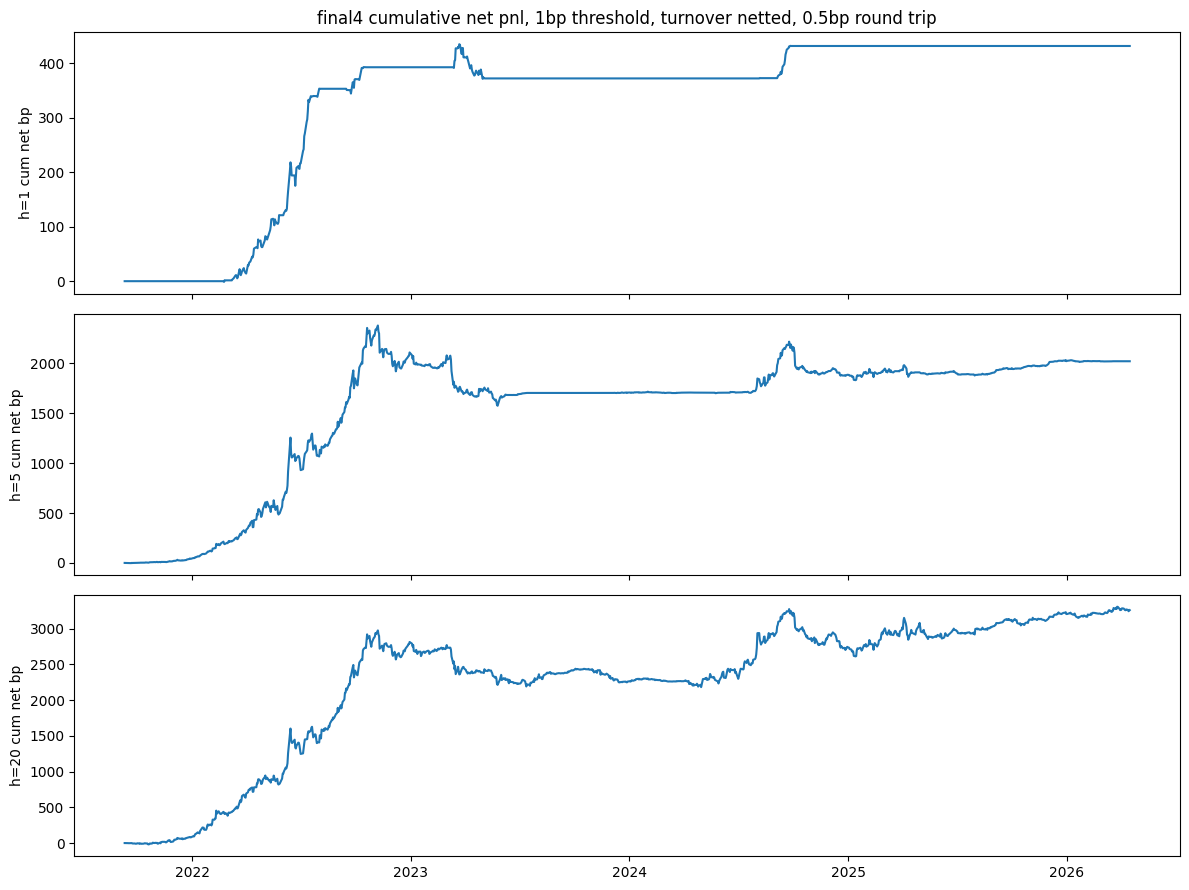

weighted directional accuracy, precommitted 1.0 bp threshold, 0.5 bp cost per trade


,horizon,trades,capture,weightedDA,nwT
0,1,222,0.3129,0.6564,3.18
1,5,3851,0.2126,0.6063,1.80
2,20,8838,0.3233,0.6616,2.19


,horizon,windowLength,windows,profitableShare,medianCapture,worstCapture
0,1,63,21,0.810,0.4563,-0.4157
1,1,126,28,0.750,0.4298,-0.4157
2,1,252,34,0.794,0.4014,-0.4157
3,5,63,50,0.600,0.1718,-0.5709
4,5,126,49,0.612,0.0912,-0.3683
5,5,252,43,0.767,0.0979,-0.2761
6,20,63,52,0.673,0.3620,-0.6630
7,20,126,49,0.755,0.3432,-0.4758
8,20,252,43,0.814,0.2248,-0.2818


In [10]:
#per-horizon arrays ordered by origin, used by the trading and weighted-DA code
originDatesByH = {}
actualArr = {}
originYieldArr = {}
final4Arr = {}
for horizon in horizons:
    rows = yieldForecasts[(yieldForecasts["model"] == "final4 EWA Ensemble")
                          & (yieldForecasts["horizon"] == horizon)]
    #pivot (not pivot_table): duplicates raise an error instead of being silently averaged
    actualPivot = rows.pivot(index="origin_date", columns="maturity", values="actual_yield")
    actualPivot = actualPivot[matList].sort_index()
    originPivot = rows.pivot(index="origin_date", columns="maturity", values="origin_yield")
    originPivot = originPivot[matList].sort_index()
    final4Pivot = rows.pivot(index="origin_date", columns="maturity", values="predicted_yield")
    final4Pivot = final4Pivot[matList].sort_index()

    originDatesByH[horizon] = list(actualPivot.index)
    actualArr[horizon] = actualPivot.to_numpy()
    originYieldArr[horizon] = originPivot.to_numpy()
    final4Arr[horizon] = final4Pivot.to_numpy()


def nwTStat(series, maxLagInput):
    #newey-west t stat on the mean of a series with the given autocovariance lag
    x = np.asarray(series)
    n = len(x)
    centered = x - x.mean()
    maxLag = min(maxLagInput, n - 2)
    variance = np.dot(centered, centered) / n
    for lag in range(1, maxLag + 1):
        variance = variance + 2.0 * np.dot(centered[lag:], centered[:-lag]) / n
    if variance <= 0.0:
        return np.nan
    return x.mean() / np.sqrt(variance / n)


def nettedBacktest(horizon, thresholdBp, universe, costPerRoundTripBp, executionDelay=0):
    #signals per origin: sign of the predicted change when it clears the threshold, else 0
    dates = originDatesByH[horizon]
    numOrigins = len(dates)
    universeIndexes = []
    for mat in universe:
        universeIndexes.append(matList.index(mat))

    predictedChangeBp = 100.0 * (final4Arr[horizon] - originYieldArr[horizon])
    signals = np.zeros((numOrigins, len(universeIndexes)))
    for t in range(numOrigins):
        for u in range(len(universeIndexes)):
            change = predictedChangeBp[t][universeIndexes[u]]
            if abs(change) >= thresholdBp:
                signals[t][u] = np.sign(change)

    #book on day t = average of the last h origins' signals (each signal is held h days)
    book = np.zeros((numOrigins, len(universeIndexes)))
    for t in range(numOrigins):
        first = max(0, t - horizon + 1)
        book[t] = signals[first : t + 1].sum(axis=0) / horizon

    #daily pnl: book times the next day's yield change; cost per side on book changes
    yieldArr = yieldDf.loc[dates][universe].to_numpy()
    dailyPnl = np.zeros(numOrigins - 1)
    dailyCost = np.zeros(numOrigins - 1)
    dailyTrade = np.zeros(numOrigins - 1)
    for t in range(numOrigins - 1):
        yieldChangeBp = 100.0 * (yieldArr[t + 1] - yieldArr[t])
        bookIndex = t - executionDelay
        if bookIndex >= 0:
            dailyPnl[t] = np.dot(book[bookIndex], yieldChangeBp)
        if t == 0:
            bookChange = np.abs(book[t])
        else:
            bookChange = np.abs(book[t] - book[t - 1])
        for u in range(len(universeIndexes)):
            costPerSide = costPerRoundTripBp[universe[u]] / 2.0
            dailyCost[t] = dailyCost[t] + costPerSide * bookChange[u]
        dailyTrade[t] = dailyTrade[t] + bookChange.sum()

    #charge liquidating the last pnl-bearing book so no position exits for free
    finalUnwind = np.abs(book[numOrigins - 2])
    for u in range(len(universeIndexes)):
        costPerSide = costPerRoundTripBp[universe[u]] / 2.0
        dailyCost[numOrigins - 2] = dailyCost[numOrigins - 2] + costPerSide * finalUnwind[u]
    dailyTrade[numOrigins - 2] = dailyTrade[numOrigins - 2] + finalUnwind.sum()

    netPnl = dailyPnl - dailyCost
    return dailyPnl.sum(), dailyCost.sum(), netPnl.sum(), nwTStat(netPnl, horizon), dailyTrade.mean(), netPnl


fullCurveCosts = {}
for mat in matList:
    fullCurveCosts[mat] = fullCurveCostBp

print("scenario 1: full 11-maturity curve, threshold sensitivity, flat", fullCurveCostBp, "bp round trip")
scenario1Rows = []
for horizon in horizons:
    for thresholdBp in thresholdSensitivity:
        gross, cost, net, tStat, turnover, netSeries = nettedBacktest(
            horizon, thresholdBp, matList, fullCurveCosts)
        scenario1Rows.append([horizon, thresholdBp, gross, cost, net, tStat, turnover])
scenario1 = pd.DataFrame(scenario1Rows,
    columns=["horizon", "thresholdBp", "grossPnlBp", "costBp", "netPnlBp", "nwT", "bookTurnoverPerDay"])
display(scenario1.round({"grossPnlBp": 0, "costBp": 0, "netPnlBp": 0, "nwT": 2, "bookTurnoverPerDay": 3}))

print("scenario 2: futures universe with per-tenor tick costs, precommitted 1bp threshold")
scenario2Rows = []
for horizon in horizons:
    gross, cost, net, tStat, turnover, netSeries = nettedBacktest(
        horizon, tradeThresholdBp, futuresList, futuresCostBp)
    stressCosts = {}
    for mat in futuresList:
        stressCosts[mat] = 2.0 * futuresCostBp[mat]
    grossS, costS, netS, tStatS, turnoverS, netSeriesS = nettedBacktest(
        horizon, tradeThresholdBp, futuresList, stressCosts)
    scenario2Rows.append([horizon, gross, cost, net, tStat, netS, tStatS])
scenario2 = pd.DataFrame(scenario2Rows,
    columns=["horizon", "grossPnlBp", "costBp", "netPnlBp", "nwT", "netPnlBp2xCost", "nwT2xCost"])
display(scenario2.round({"grossPnlBp": 0, "costBp": 0, "netPnlBp": 0, "nwT": 2, "netPnlBp2xCost": 0, "nwT2xCost": 2}))

print("scenario 3: execution delay sensitivity, full curve, 1bp threshold")
scenario3Rows = []
for horizon in horizons:
    gross, cost, net, tStat, turnover, netSeries = nettedBacktest(
        horizon, tradeThresholdBp, matList, fullCurveCosts, executionDelay=1)
    scenario3Rows.append([horizon, gross, cost, net, tStat])
scenario3 = pd.DataFrame(scenario3Rows, columns=["horizon", "grossPnlBp", "costBp", "netPnlBp", "nwT"])
display(scenario3.round({"grossPnlBp": 0, "costBp": 0, "netPnlBp": 0, "nwT": 2}))

#cumulative net pnl for the headline rule
fig, axes = plt.subplots(len(horizons), 1, figsize=(12, 9), sharex=True)
for axisIndex in range(len(horizons)):
    horizon = horizons[axisIndex]
    gross, cost, net, tStat, turnover, netSeries = nettedBacktest(
        horizon, tradeThresholdBp, matList, fullCurveCosts)
    axes[axisIndex].plot(originDatesByH[horizon][1:], np.cumsum(netSeries))
    axes[axisIndex].set_ylabel("h=" + str(horizon) + " cum net bp")
axes[0].set_title("final4 cumulative net pnl, 1bp threshold, turnover netted, 0.5bp round trip")
plt.tight_layout()
plt.show()

print("weighted directional accuracy, precommitted", tradeThresholdBp, "bp threshold,",
      fullCurveCostBp, "bp cost per trade")
wdaRows = []
windowRows = []
for horizon in horizons:
    predictedChangeBp = 100.0 * (final4Arr[horizon] - originYieldArr[horizon])
    actualChangeBp = 100.0 * (actualArr[horizon] - originYieldArr[horizon])
    numOrigins = len(originDatesByH[horizon])

    #per-origin pnl and available bp with the threshold applied
    originPnl = np.zeros(numOrigins)
    originAbs = np.zeros(numOrigins)
    tradeCount = 0
    for t in range(numOrigins):
        for matIndex in range(len(matList)):
            change = predictedChangeBp[t][matIndex]
            if abs(change) >= tradeThresholdBp and change != 0.0:
                originPnl[t] = originPnl[t] + np.sign(change) * actualChangeBp[t][matIndex] - fullCurveCostBp
                originAbs[t] = originAbs[t] + abs(actualChangeBp[t][matIndex])
                tradeCount = tradeCount + 1

    capture = originPnl.sum() / originAbs.sum()
    weightedDa = (1.0 + capture) / 2.0
    activePnl = originPnl[originAbs > 0]
    tStat = nwTStat(activePnl, horizon - 1)
    wdaRows.append([horizon, tradeCount, capture, weightedDa, tStat])

    for windowLength in backtestWindows:
        captures = []
        for start in range(0, max(1, numOrigins - windowLength), backtestStep):
            windowPnl = originPnl[start : start + windowLength].sum()
            windowAbs = originAbs[start : start + windowLength].sum()
            if windowAbs > 0:
                captures.append(windowPnl / windowAbs)
        captures = np.array(captures)
        windowRows.append([horizon, windowLength, len(captures), np.mean(captures > 0),
                           np.median(captures), captures.min()])

wdaTable = pd.DataFrame(wdaRows, columns=["horizon", "trades", "capture", "weightedDA", "nwT"])
display(wdaTable.round({"capture": 4, "weightedDA": 4, "nwT": 2}))

windowTable = pd.DataFrame(windowRows,
    columns=["horizon", "windowLength", "windows", "profitableShare", "medianCapture", "worstCapture"])
display(windowTable.round({"profitableShare": 3, "medianCapture": 4, "worstCapture": 4}))

#### Save everything and the numbers for the paper

All tables go to `data/generated/final4_results/`. The closing cell prints the headline numbers in one place for paper writing. Read them with the standing caveats: the holdout was inspected during development, equal notional ignores DV01, and the futures universe is the implementable scenario.

In [11]:
resultsDir = dataDir / "generated" / "final4_results"
resultsDir.mkdir(parents=True, exist_ok=True)

#long format kept identical to final2/final3 so downstream scripts can consume any file
final4Long = yieldForecasts[yieldForecasts["model"] == "final4 EWA Ensemble"].copy()
final4Long["error_bp"] = 100.0 * (final4Long["actual_yield"] - final4Long["predicted_yield"])
final4Long["actual_change"] = final4Long["actual_yield"] - final4Long["origin_yield"]
final4Long["predicted_change"] = final4Long["predicted_yield"] - final4Long["origin_yield"]
final4Long.to_csv(resultsDir / "yield_forecasts.csv", index=False)

accuracyTable.to_csv(resultsDir / "accuracy_table.csv", index=False)
dmResults.to_csv(resultsDir / "dm_tests.csv", index=False)
spaResults.to_csv(resultsDir / "spa_reality_check.csv", index=False)
tuningResults.to_csv(resultsDir / "training_only_tuning.csv", index=False)
scenario1.to_csv(resultsDir / "trading_full_curve.csv", index=False)
scenario2.to_csv(resultsDir / "trading_futures_universe.csv", index=False)
scenario3.to_csv(resultsDir / "trading_execution_delay.csv", index=False)
wdaTable.to_csv(resultsDir / "weighted_da.csv", index=False)
windowTable.to_csv(resultsDir / "weighted_da_rolling_windows.csv", index=False)
weightPathDf.to_csv(resultsDir / "ewa_weight_path.csv", index=False)

print("saved final4 results to", resultsDir)
print()
print("================ NUMBERS FOR THE PAPER ================")
for horizon in horizons:
    rwRow = accuracyTable[(accuracyTable["model"] == "Random Walk") & (accuracyTable["horizon"] == horizon)]
    f4Row = accuracyTable[(accuracyTable["model"] == "final4 EWA Ensemble") & (accuracyTable["horizon"] == horizon)]
    dmRow = dmResults[(dmResults["modelA"] == "final4 EWA Ensemble")
                      & (dmResults["modelB"] == "Random Walk") & (dmResults["horizon"] == horizon)]
    spaRow = spaResults[spaResults["horizon"] == horizon]
    wdaRow = wdaTable[wdaTable["horizon"] == horizon]
    print("h =", horizon)
    print("  rmse: final4", round(float(f4Row["curveRmseBp"].iloc[0]), 2),
          "bp vs random walk", round(float(rwRow["curveRmseBp"].iloc[0]), 2), "bp")
    print("  directional accuracy:", round(float(f4Row["directionalAccuracy"].iloc[0]), 3),
          "vs base rate", round(float(f4Row["daBaseRate"].iloc[0]), 3))
    print("  DM vs RW: stat", round(float(dmRow["dmStatistic"].iloc[0]), 2),
          " p", round(float(dmRow["pValue"].iloc[0]), 4),
          " BH q", round(float(dmRow["qValueBH"].iloc[0]), 4))
    print("  SPA reality check p:", round(float(spaRow["spaPValue"].iloc[0]), 4))
    print("  weighted DA (1bp threshold, 0.5bp cost):", round(float(wdaRow["weightedDA"].iloc[0]), 4),
          " NW t:", round(float(wdaRow["nwT"].iloc[0]), 2))
    print()

saved final4 results to ..\data\generated\final4_results

================ NUMBERS FOR THE PAPER ================
h = 1
  rmse: final4 6.1 bp vs random walk 6.11 bp
  directional accuracy: 0.524 vs base rate 0.514
  DM vs RW: stat -2.68  p 0.0075  BH q 0.0531
  SPA reality check p: 0.0105
  weighted DA (1bp threshold, 0.5bp cost): 0.6564  NW t: 3.18

h = 5
  rmse: final4 13.05 bp vs random walk 13.19 bp
  directional accuracy: 0.551 vs base rate 0.557
  DM vs RW: stat -2.0  p 0.0462  BH q 0.0832
  SPA reality check p: 0.0405
  weighted DA (1bp threshold, 0.5bp cost): 0.6063  NW t: 1.8

h = 20
  rmse: final4 26.82 bp vs random walk 28.03 bp
  directional accuracy: 0.588 vs base rate 0.57
  DM vs RW: stat -1.81  p 0.071  BH q 0.1066
  SPA reality check p: 0.066
  weighted DA (1bp threshold, 0.5bp cost): 0.6616  NW t: 2.19

